In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# Load data
df = pd.read_csv('supermarket_sales - Sheet1.csv')
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [10]:
# Clean Data
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [28]:
# Analyze Data
total_revenue = df["Total"].sum()
print("Total Revenue : ", total_revenue)

best_selling = df.groupby("Product line")["Quantity"].sum().sort_values(ascending = False)
print("\nBest Selling Products:\n", best_selling)

highest_revenue = df.groupby("Product line")["Total"].sum().sort_values(ascending = False)
print("\nHighest Revenue by Categories:\n", highest_revenue)

sales_by_branch = df.groupby("Branch")["Total"].sum().sort_values(ascending = False)
print("\nSales by branch:\n", sales_by_branch)

df["Date"] = pd.to_datetime(df["Date"])
daily_sales = df.groupby("Date")["Total"].sum().sort_values(ascending = False)
print("\nDaily Sales:\n", daily_sales)

Total Revenue :  322966.749

Best Selling Products:
 Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64

Highest Revenue by Categories:
 Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

Sales by branch:
 Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64

Daily Sales:
 Date
2019-03-09    7474.0470
2019-02-07    7228.2105
2019-03-14    7214.6340
2019-02-15    6830.7855
2019-03-02    6560.3055
                ...    
2019-02-18    1496.0295
2019-03-07    1438.2585
2019-02-21    1393.7385
2019-03-18    1292.8335
2019-02-13     934.2375
Name: Total, Length: 89, dtype: float64


In [32]:
average_sale = np.mean(df["Total"])
print("Average Sale:", average_sale)

max_sale = np.max(df["Total"])
print("Highest Sale:", max_sale)

min_sale = np.min(df["Total"])
print("Lowest Sale:", min_sale)

std_sale = np.std(df["Total"])
print("Standard Deviation:", std_sale)

average_quantity = np.mean(df["Quantity"])
print("Average Quantity:", average_quantity)

Average Sale: 322.966749
Highest Sale: 1042.65
Lowest Sale: 10.6785
Standard Deviation: 245.76236168237725
Average Quantity: 5.51


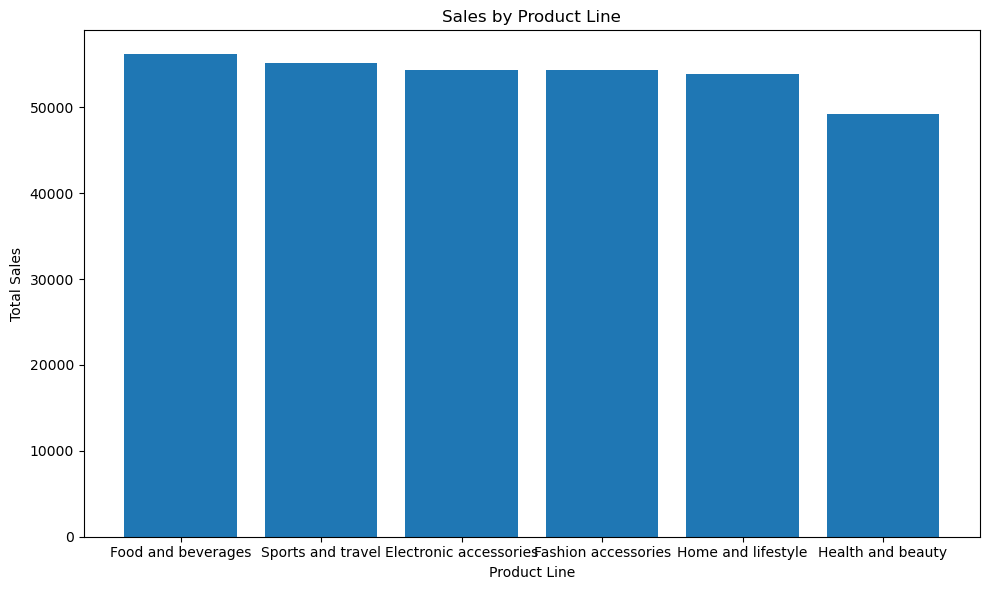

In [36]:
## Visualization

plt.figure(figsize=(10, 6))

plt.bar(highest_revenue.index, highest_revenue.values)

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'N.o of Transactions')

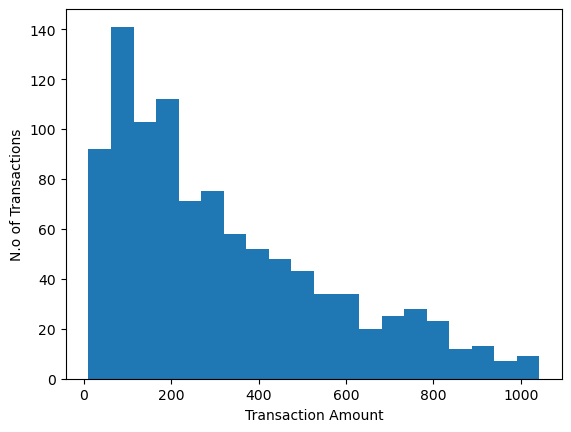

In [43]:
## chart 3

plt.hist(df["Total"], bins=20)

plt.xlabel("Transaction Amount")
plt.ylabel("N.o of Transactions")

In [ ]:
## chart 3

df["Time"] = pd.to_datetime(df["Time"])
df["Hour"] = df["Time"].dt.hour 

df["Day"] = df["Date"].dt.day_name()

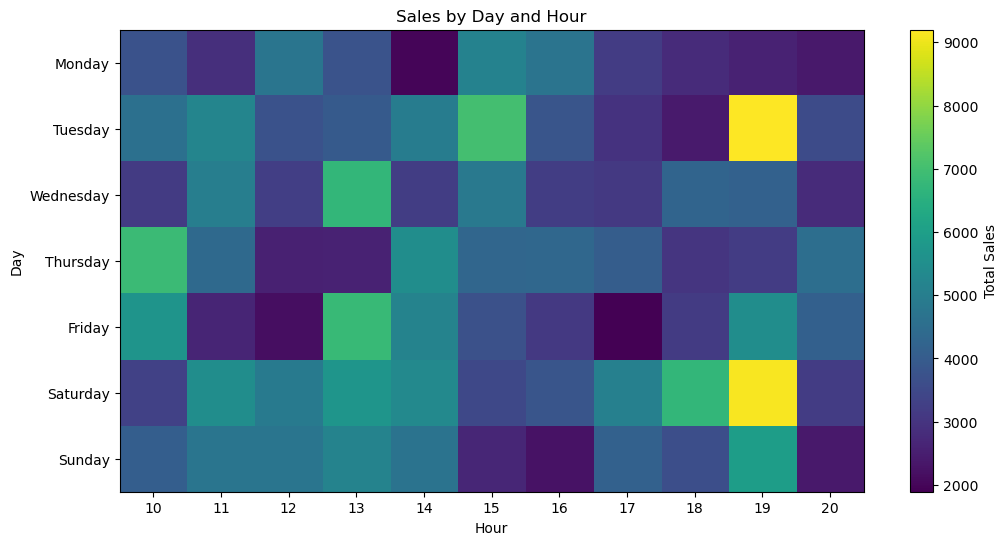

In [49]:
heatmap_data = df.pivot_table(
    values="Total",
    index="Day",
    columns="Hour",
    aggfunc="sum"
)

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 6))

plt.imshow(heatmap_data, aspect="auto")

plt.colorbar(label="Total Sales")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.xlabel("Hour")
plt.ylabel("Day")
plt.title("Sales by Day and Hour")

plt.show()

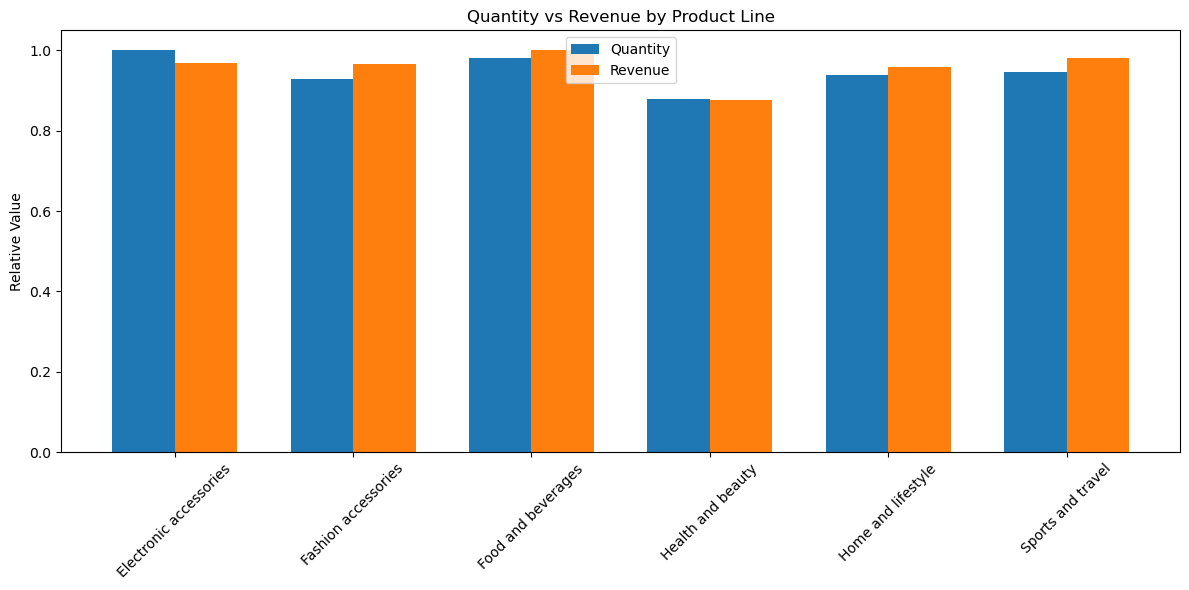

In [52]:
## chart 4:

product_analysis = df.groupby("Product line")[["Quantity", "Total"]].sum()

chart_data = product_analysis.copy()

chart_data["Quantity"] = chart_data["Quantity"] / chart_data["Quantity"].max()
chart_data["Revenue"] = chart_data["Total"] / chart_data["Total"].max()

x = np.arange(len(chart_data))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, chart_data["Quantity"], width, label="Quantity")
plt.bar(x + width/2, chart_data["Revenue"], width, label="Revenue")

plt.xticks(x, chart_data.index, rotation=45)
plt.ylabel("Relative Value")
plt.title("Quantity vs Revenue by Product Line")
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
print("1. Food and beverages generated the highest total sales, while health and beauty generated the lowest.")
print("2. Most customer transactions have relatively low values, while high-value transactions occur less frequently.")
print("3. Sales vary significantly by day and hour, with 7 PM showing particularly high sales on some days, especially Tuesday and Saturday.")
print("4. Food and beverages performs strongly in both quantity sold and revenue, while health and beauty performs relatively lower in both measures.")
print("5. The analysis shows that sales are influenced by both product category and shopping time, which can help the supermarket optimize inventory and staffing.")

1. Food and beverages generated the highest total sales, while health and beauty generated the lowest.
2. Most customer transactions have relatively low values, while high-value transactions occur less frequently.
3. Sales vary significantly by day and hour, with 7 PM showing particularly high sales on some days, especially Tuesday and Saturday.
4. Food and beverages performs strongly in both quantity sold and revenue, while health and beauty performs relatively lower in both measures.
5. The analysis shows that sales are influenced by both product category and shopping time, which can help the supermarket optimize inventory and staffing.
